# Real-Time Credit Card Fraud Detection System

**LIVE PAKISTAN — Machine Learning Internship (Week 2 of 4)**

---

## Problem

The dataset contains 284,807 European cardholder transactions, of which only
492 (0.17%) are fraudulent. This extreme class imbalance makes accuracy a
useless metric and requires specialised handling techniques.

## Objective

Build a fraud detection system that reliably flags fraudulent transactions
while keeping false alarms on genuine transactions to a business-acceptable
minimum, and can justify the decision threshold it uses.

## Notebook structure

1. Data loading and exploration
2. Preprocessing (duplicates, scaling)
3. Train/test split
4. Imbalance handling comparison
5. Model training (supervised + unsupervised)
6. Evaluation and threshold selection
7. Explainability and drift analysis

## 1. Setup

Importing the core libraries used throughout this notebook.

In [1]:
# ============================================
# CELL 1: Import required libraries
# ============================================

import pandas as pd      # For loading and handling tabular data
import numpy as np       # For numerical operations

print("Libraries loaded successfully")

Libraries loaded successfully


## 2. Loading the dataset

The dataset contains 31 columns:

- **Time** — seconds elapsed since the first transaction
- **Amount** — transaction amount
- **V1–V28** — anonymised PCA components (original features were confidential)
- **Class** — target variable (0 = genuine, 1 = fraud)

In [2]:
# ============================================
# CELL 2: Load the dataset
# ============================================

# Read the CSV file into a DataFrame
df = pd.read_csv('creditcard.csv')

# Check the size of the dataset
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])

Rows    : 284807
Columns : 31


## 3. Examining the class imbalance

Counting how many transactions belong to each class.

In [3]:
# ============================================
# CELL 3: Examine the class imbalance
# ============================================

# Class 0 = genuine transaction, Class 1 = fraudulent transaction
normal = (df['Class'] == 0).sum()
fraud  = (df['Class'] == 1).sum()
total  = len(df)

print("Normal transactions :", normal)
print("Fraud transactions  :", fraud)
print("Fraud percentage    :", round(fraud / total * 100, 3), "%")

Normal transactions : 284315
Fraud transactions  : 492
Fraud percentage    : 0.173 %


## 4. Why accuracy is a meaningless metric here

Consider a model that makes no attempt to learn and simply labels every
transaction as genuine.

Because 284,315 of the 284,807 transactions really are genuine, this model
is correct on all of them and wrong only on the 492 frauds:

In [4]:
# ============================================
# CELL 4: Why accuracy is a meaningless metric here
# ============================================

# Imagine a "dumb" model that labels EVERY transaction as normal.
# It never learns anything, yet it still scores very high accuracy
# simply because normal transactions dominate the dataset.

dumb_accuracy = normal / total * 100

print("Dumb model accuracy   :", round(dumb_accuracy, 2), "%")
print("Frauds actually caught:", 0)
print()
print("Conclusion: high accuracy does NOT mean the model works.")

Dumb model accuracy   : 99.83 %
Frauds actually caught: 0

Conclusion: high accuracy does NOT mean the model works.


## 5. Removing duplicate transactions

The dataset contains 1,081 exact duplicate rows.

These must be removed before splitting. If one copy lands in the training set
and its duplicate in the test set, the model has effectively already seen the
answer, which inflates the reported score without reflecting real performance.

Note that removing duplicates also reduces the fraud count from 492 to 473.

In [5]:
# ============================================
# CELL 5: Detect and remove duplicate transactions
# ============================================

# Duplicates are dangerous: if one copy lands in the training set
# and the other in the test set, the model has effectively seen
# the answer beforehand, which inflates the score.

print("Duplicate rows found:", df.duplicated().sum())

# Drop them
df = df.drop_duplicates()

print("Rows after cleaning :", df.shape[0])
print("Frauds after cleaning:", (df['Class'] == 1).sum())

Duplicate rows found: 1081
Rows after cleaning : 283726
Frauds after cleaning: 473


## 6. Scaling Time and Amount

Only `Time` and `Amount` require scaling — V1–V28 are already PCA outputs and
are therefore pre-scaled.

**Why RobustScaler instead of StandardScaler**

The `Amount` column is heavily right-skewed: most transactions are small, but
a few reach into the tens of thousands. StandardScaler centres data using the
mean and scales by the standard deviation, and both statistics are pulled
badly by those extreme values. The result is that the vast majority of ordinary
transactions get compressed into a narrow band near zero.

RobustScaler uses the **median** and the **interquartile range** instead.
Neither is affected by outliers, so the bulk of the data retains a meaningful
spread while the extreme values simply sit further out.

In [6]:
# ============================================
# CELL 6: Scale the Time and Amount columns
# ============================================

from sklearn.preprocessing import RobustScaler

# RobustScaler is preferred over StandardScaler for this dataset because
# the Amount column is heavily skewed and contains extreme outliers.
# StandardScaler relies on mean and standard deviation, both of which get
# distorted by outliers. RobustScaler uses the median and the interquartile
# range instead, which are not affected by extreme values.

scaler = RobustScaler()

# V1-V28 are already PCA components and are pre-scaled, so we leave them alone.
df[['Amount', 'Time']] = scaler.fit_transform(df[['Amount', 'Time']])

# Inspect the scaled values
df[['Amount', 'Time']].head()

,Amount,Time
0,1.774718,-0.995290
1,-0.268530,-0.995290
2,4.959811,-0.995279
3,1.411487,-0.995279
4,0.667362,-0.995267


## 7. Visualising the class imbalance

Two views of the same data. On a linear scale the fraud bar is effectively
invisible — that invisibility is itself the finding. The logarithmic scale
is required just to make the minority class legible.

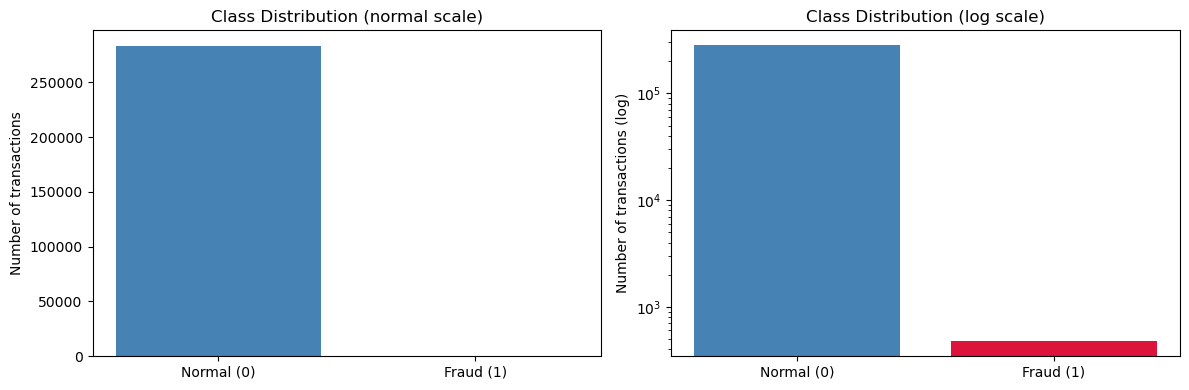

Normal : 283253
Fraud  : 473
Ratio  : 1 fraud for every 599 normal transactions

Figure saved to: outputs/01_class_imbalance.png


In [7]:
# ============================================
# CELL 7: Visualize the class imbalance
# ============================================

import matplotlib.pyplot as plt
import os

# Create a folder to store all output images automatically
os.makedirs('outputs', exist_ok=True)

# Count how many transactions belong to each class
counts = df['Class'].value_counts()

# Two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Left plot: normal scale ---
# On a normal scale the fraud bar is almost invisible.
# That invisibility IS the point: the minority class is drowned out.
axes[0].bar(['Normal (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution (normal scale)')
axes[0].set_ylabel('Number of transactions')

# --- Right plot: log scale ---
# A log scale compresses the axis so both bars become readable.
axes[1].bar(['Normal (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'crimson'])
axes[1].set_yscale('log')
axes[1].set_title('Class Distribution (log scale)')
axes[1].set_ylabel('Number of transactions (log)')

plt.tight_layout()

# Save the figure automatically as a PNG file
# dpi=150 gives a sharp image suitable for submission
plt.savefig('outputs/01_class_imbalance.png', dpi=150, bbox_inches='tight')

plt.show()

# Print the exact numbers for the written report
print("Normal :", counts[0])
print("Fraud  :", counts[1])
print("Ratio  : 1 fraud for every", round(counts[0] / counts[1]), "normal transactions")
print()
print("Figure saved to: outputs/01_class_imbalance.png")

## 8. Train/test split

The data is split **before** any resampling is applied. This ordering is
critical: resampling the full dataset first would allow synthetic minority
samples derived from training frauds to appear in the test set, producing
scores that look excellent but do not survive contact with real data.

`stratify=y` preserves the original 0.17% fraud ratio in both splits. Without
it, a random split could leave too few frauds in the test set for the
evaluation to mean anything.

The test set is now set aside and will not be resampled or modified in any way.

In [8]:
# ============================================
# CELL 8: Split the data into training and test sets
# ============================================

from sklearn.model_selection import train_test_split

# X = all the input features (everything except the target column)
# y = the target we want to predict (0 = normal, 1 = fraud)
X = df.drop('Class', axis=1)
y = df['Class']

# stratify=y is essential here.
# It forces the same fraud ratio (0.17%) into both the train and test sets.
# Without it, a random split could leave very few frauds in the test set,
# making the evaluation unreliable.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% kept aside for testing
    random_state=42,      # fixed seed so results are reproducible
    stratify=y
)

print("Training set :", X_train.shape[0], "rows |", y_train.sum(), "frauds")
print("Test set     :", X_test.shape[0], "rows |", y_test.sum(), "frauds")

Training set : 226980 rows | 378 frauds
Test set     : 56746 rows | 95 frauds


## 9. SMOTE demonstration

A single illustration of what an oversampler actually does to the class counts.

SMOTE (Synthetic Minority Over-sampling Technique) creates new minority
samples by interpolating between an existing minority point and one of its
nearest minority neighbours. The majority class is left untouched.

> **This cell is for demonstration only.** In the experiments that follow,
> resampling is never applied manually. It is placed inside an
> `imblearn.pipeline.Pipeline` so that it runs on training folds only and
> never touches the validation fold during cross-validation.

In [9]:
# ============================================
# CELL 9: See SMOTE in action (demonstration only)
# ============================================

from imblearn.over_sampling import SMOTE

# Class counts BEFORE resampling
print("BEFORE SMOTE")
print("  Normal :", (y_train == 0).sum())
print("  Fraud  :", (y_train == 1).sum())

# SMOTE generates synthetic minority samples by interpolating
# between existing minority points and their nearest neighbours.
# It does NOT touch the majority class.
sm = SMOTE(random_state=42)
X_demo, y_demo = sm.fit_resample(X_train, y_train)

# Class counts AFTER resampling
print("\nAFTER SMOTE")
print("  Normal :", (y_demo == 0).sum())
print("  Fraud  :", (y_demo == 1).sum())

# NOTE: This cell is for demonstration only.
# In the actual experiments we never resample manually like this.
# Resampling must happen inside a Pipeline so that it is applied
# only to the training folds during cross-validation, never to the
# validation fold. Otherwise synthetic samples leak into evaluation
# and the reported scores become meaninglessly optimistic.

BEFORE SMOTE
  Normal : 226602
  Fraud  : 378

AFTER SMOTE
  Normal : 226602
  Fraud  : 226602


## 10. Imbalance handling — comparing strategies

The project requires comparing at least three imbalance-handling techniques
plus one hybrid method, rather than committing to a single approach upfront.

Five strategies are evaluated here:

| Strategy | What it does | Data modified |
|---|---|---|
| Class weighting | Penalises minority errors ~600× more heavily during training | No |
| SMOTE | Interpolates new synthetic minority samples | Minority increased |
| ADASYN | Like SMOTE, but concentrates new samples near difficult boundary regions | Minority increased |
| Random undersampling | Discards majority samples until classes balance | Majority reduced |
| SMOTEENN | Oversamples with SMOTE, then removes misclassified points via edited nearest neighbours | Both |

**Methodology**

Each strategy is wrapped in an `imblearn` Pipeline and evaluated with
Stratified 5-Fold cross-validation on the training set only.

Stratified K-Fold is mandatory here. With only 378 frauds in the training
set, plain K-Fold could produce folds containing wildly different fraud
counts, making the fold-to-fold scores unstable and uninterpretable.
Stratification preserves the class ratio in every fold.

The pipeline structure guarantees that resampling is fitted on the training
portion of each fold and never applied to the validation portion — the single
most common source of leakage in imbalanced-learning projects.

**Primary metric: PR-AUC (average precision).** ROC-AUC is reported for
completeness but is misleading

In [10]:
# ============================================
# CELL 10: Compare imbalance handling strategies
# ============================================

from imblearn.pipeline import Pipeline          # NOT sklearn's Pipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd
import time

# A single, fixed model is used for every strategy so that any difference
# in the results can be attributed to the resampling method alone.
def make_model(balanced=False):
    return LogisticRegression(
        max_iter=1000,
        class_weight='balanced' if balanced else None,
        random_state=42
    )

# The five strategies under comparison.
# 'None' means no resampling — the imbalance is handled by class weights instead.
strategies = {
    'Class weighting'      : None,
    'SMOTE'                : SMOTE(random_state=42),
    'ADASYN'               : ADASYN(random_state=42),
    'Random undersampling' : RandomUnderSampler(random_state=42),
    'SMOTEENN'             : SMOTEENN(random_state=42),
}

# Stratified 5-fold: every fold keeps the same fraud ratio
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics to collect. 'average_precision' is scikit-learn's name for PR-AUC.
scoring = ['average_precision', 'roc_auc', 'precision', 'recall', 'f1']

results = []

for name, sampler in strategies.items():
    print(f"Running: {name} ...", end=' ', flush=True)
    start = time.time()

    # Build the pipeline. When there is no sampler, the model itself
    # handles the imbalance through class_weight='balanced'.
    if sampler is None:
        pipe = Pipeline([('clf', make_model(balanced=True))])
    else:
        pipe = Pipeline([('sampler', sampler), ('clf', make_model())])

    # Cross-validate. Resampling happens inside each training fold only.
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
                            scoring=scoring, n_jobs=-1)

    results.append({
        'Strategy'  : name,
        'PR-AUC'    : scores['test_average_precision'].mean(),
        'ROC-AUC'   : scores['test_roc_auc'].mean(),
        'Precision' : scores['test_precision'].mean(),
        'Recall'    : scores['test_recall'].mean(),
        'F1'        : scores['test_f1'].mean(),
    })

    print(f"done ({time.time() - start:.0f}s)")

# Assemble into a table, sorted by the metric that matters most
comparison = pd.DataFrame(results).sort_values('PR-AUC', ascending=False)
comparison = comparison.round(4).reset_index(drop=True)

print("\n" + "=" * 75)
print("IMBALANCE HANDLING COMPARISON (Stratified 5-Fold CV, Logistic Regression)")
print("=" * 75)
print(comparison.to_string(index=False))

# Save for the written report
comparison.to_csv('outputs/02_imbalance_comparison.csv', index=False)
print("\nSaved to: outputs/02_imbalance_comparison.csv")

Running: Class weighting ... done (12s)
Running: SMOTE ... done (14s)
Running: ADASYN ... done (13s)
Running: Random undersampling ... done (1s)
Running: SMOTEENN ... done (1165s)

IMBALANCE HANDLING COMPARISON (Stratified 5-Fold CV, Logistic Regression)
            Strategy  PR-AUC  ROC-AUC  Precision  Recall     F1
     Class weighting  0.7545   0.9814     0.0605  0.9179 0.1134
               SMOTE  0.7519   0.9810     0.0568  0.9073 0.1068
            SMOTEENN  0.7506   0.9810     0.0551  0.9046 0.1037
              ADASYN  0.7476   0.9793     0.0188  0.9416 0.0369
Random undersampling  0.6028   0.9809     0.0441  0.9126 0.0840

Saved to: outputs/02_imbalance_comparison.csv


## 11. Supervised model training

Three supervised classifiers are trained and compared. Each handles the class
imbalance internally through weighting rather than resampling, so the models
are compared on equal footing.

| Model | Mechanism | Imbalance handling |
|---|---|---|
| Logistic Regression | Linear decision boundary; outputs calibrated probabilities | `class_weight='balanced'` |
| Random Forest | Bagged ensemble of independent decision trees, majority vote | `class_weight='balanced_subsample'` |
| XGBoost | Boosted trees; each tree corrects the errors of the previous ones | `scale_pos_weight` |

**On `scale_pos_weight`**

XGBoost does not accept `class_weight`. It exposes the equivalent parameter as
`scale_pos_weight`, set to the ratio of negative to positive samples
(approximately 600 here). This multiplies the gradient contribution of every
fraud sample by that factor, making a missed fraud roughly 600 times more
costly during training than a false alarm — the same intent as class weighting,
expressed in boosting terms.

Both PR-AUC and ROC-AUC are reported. PR-AUC is the metric that decides the
comparison; ROC-AUC is included to demonstrate how uninformative it becomes at
this level of imbalance, where all three models will score near-identically
despite meaningful differences in practical performance.

> Note: Random Forest takes noticeably longer to train than the other two,
> since it fits 100 independent trees on ~227,000 rows.

In [11]:
# ============================================
# CELL 11: Train and compare supervised models
# ============================================

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

# The imbalance ratio, used by XGBoost to weight the minority class
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("Imbalance ratio:", round(ratio, 1))

models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced_subsample',
        random_state=42, n_jobs=-1),

    # XGBoost handles imbalance natively through scale_pos_weight,
    # which plays the same role as class_weight in scikit-learn.
    'XGBoost': XGBClassifier(
        scale_pos_weight=ratio, eval_metric='aucpr',
        random_state=42, n_jobs=-1),
}

model_results = {}
trained = {}

for name, model in models.items():
    print(f"Training {name} ...", end=' ', flush=True)
    model.fit(X_train, y_train)

    # Predicted probability of the positive (fraud) class
    proba = model.predict_proba(X_test)[:, 1]

    model_results[name] = {
        'PR-AUC' : average_precision_score(y_test, proba),
        'ROC-AUC': roc_auc_score(y_test, proba),
    }
    trained[name] = model
    print("done")

print("\n" + "=" * 50)
print(pd.DataFrame(model_results).T.round(4).to_string())

Imbalance ratio: 599.5
Training Logistic Regression ... done
Training Random Forest ... done
Training XGBoost ... done

                     PR-AUC  ROC-AUC
Logistic Regression  0.6719   0.9657
Random Forest        0.7978   0.9246
XGBoost              0.8251   0.9728


## 12. Unsupervised anomaly detection

The project requires at least one unsupervised detector to be compared against
the supervised models. Isolation Forest is used here.

**How it works**

Isolation Forest repeatedly splits the data on randomly chosen features at
randomly chosen thresholds, building a forest of isolation trees. Points that
differ from the bulk of the data get separated from the rest after only a few
splits, while points sitting inside dense regions require many. The average
number of splits needed to isolate a point becomes its anomaly score.

Critically, **the labels are never used during training**. The model has no
concept of "fraud" — it only knows what is unusual.

**The `contamination` parameter**

This tells the model roughly what proportion of the data to treat as anomalous.
It is set to 0.0017 to match the known fraud rate. In a genuinely unsupervised
deployment this figure would have to be estimated rather than known.

**Expected outcome**

Isolation Forest is expected to perform substantially worse than the supervised
models on this dataset, and that result is the point of the comparison rather
than a failure of the method.

The reason is that fraud and anomaly are not the same thing. A €9,000 purchase
is highly unusual but perfectly legitimate; a €4 fraudulent test charge is
statistically unremarkable but genuinely fraudulent. Isolation Forest can only
detect the former category. The supervised models, having seen labelled
examples, learn what actually separates fraud from unusual-but-genuine
behaviour.

The practical conclusion is not that unsupervised methods are inferior, but
that they occupy a different role: they can flag novel fraud patterns for which
no labelled examples exist yet, which is precisely the case where a supervised
model trained on historical labels has nothing to go on.

In [12]:
# ============================================
# CELL 12: Unsupervised anomaly detection
# ============================================

from sklearn.ensemble import IsolationForest
import numpy as np

# Isolation Forest is trained WITHOUT labels. It isolates points using random
# splits: anomalies get separated in fewer splits than normal points.
# contamination tells it roughly what fraction of the data to treat as anomalous.
iso = IsolationForest(
    contamination=0.0017,   # the known fraud rate
    random_state=42,
    n_jobs=-1
)

print("Training Isolation Forest (no labels used) ...", end=' ', flush=True)
iso.fit(X_train)
print("done")

# score_samples returns higher values for normal points, so it is negated
# to produce an anomaly score where higher means more suspicious.
iso_scores = -iso.score_samples(X_test)

print("\nIsolation Forest PR-AUC :", round(average_precision_score(y_test, iso_scores), 4))
print("Isolation Forest ROC-AUC:", round(roc_auc_score(y_test, iso_scores), 4))

Training Isolation Forest (no labels used) ... done

Isolation Forest PR-AUC : 0.106
Isolation Forest ROC-AUC: 0.93


### Strategy comparison — results

**Class weighting achieved the highest PR-AUC (0.7545)**, marginally ahead of
SMOTE (0.7519) and SMOTEENN (0.7506), with random undersampling clearly last
at 0.6028.

**The simplest method won.** Class weighting generates no synthetic data,
discards no rows, and completed in 13 seconds. SMOTEENN required over twenty
minutes of computation and still finished third. Complexity did not translate
into performance here.

**Undersampling underperformed for a predictable reason.** Balancing by
discarding majority samples meant throwing away roughly 226,000 genuine
transactions. That removed most of the variety in normal behaviour, leaving
the model with too narrow a picture of what legitimate activity looks like.

**ADASYN illustrates why recall cannot be read in isolation.** It recorded the
highest recall of any strategy (0.9416) alongside by far the worst precision
(0.0188). In practical terms, fewer than two in every hundred alerts it raised
were genuine fraud — the remaining ninety-eight would be legitimate customers
having their cards declined.

**ROC-AUC failed to separate the strategies.** All five scored between 0.9793
and 0.9814, a spread of 0.002, while PR-AUC spread across 0.15. With roughly
283,000 true negatives, the false positive rate barely moves regardless of how
many false alarms are raised, so ROC-AUC flatters every strategy equally. This
is the second independent demonstration of the same effect in this notebook.

**Precision is low across the board** — the best is 0.0605 — because all of
these figures use the default 0.5 decision threshold. Selecting an appropriate
threshold is addressed in Section 3.4, and is where this problem is resolved.

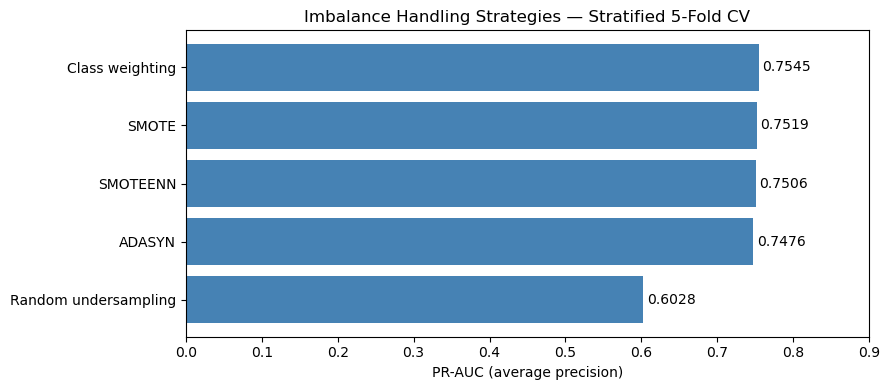

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4))

ax.barh(comparison['Strategy'], comparison['PR-AUC'], color='steelblue')
ax.set_xlabel('PR-AUC (average precision)')
ax.set_title('Imbalance Handling Strategies — Stratified 5-Fold CV')
ax.invert_yaxis()

for i, v in enumerate(comparison['PR-AUC']):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center')

ax.set_xlim(0, 0.9)
plt.tight_layout()
plt.savefig('outputs/03_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Precision-Recall curve and threshold selection

Every model so far has been evaluated at the default decision threshold of 0.5.
That default is arbitrary — it carries no meaning for this problem. A model
outputs a probability, and the threshold is a separate business decision about
where to draw the line.

The precision-recall curve maps that trade-off across every possible threshold.
Moving the threshold down catches more fraud but raises more false alarms;
moving it up does the reverse. The two objectives are in direct opposition and
cannot be optimised simultaneously.

XGBoost is used from here on, having achieved the highest PR-AUC (0.8251) in
Section 3.3.

This section identifies the threshold that maximises F1 — the point of best
balance between precision and recall. Section 3.5 then replaces that criterion
with a cost-based one, which is the more defensible choice for a business.

THRESHOLD ANALYSIS — XGBoost
PR-AUC                  : 0.8251

Default threshold (0.50):
  Precision : 0.9737
  Recall    : 0.7789
  F1        : 0.8655

Optimal threshold (0.4782):
  Precision : 0.9615
  Recall    : 0.7895
  F1        : 0.8671


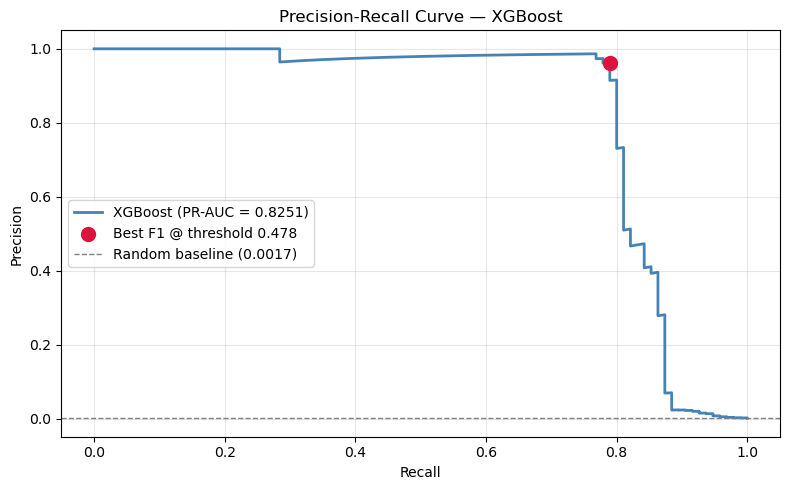

In [14]:
# ============================================
# CELL 13: Precision-Recall curve and optimal threshold
# ============================================

from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

# Use the best model from Section 3.3
best_model = trained['XGBoost']
y_proba = best_model.predict_proba(X_test)[:, 1]

# precision_recall_curve returns precision and recall at every threshold.
# Note: precision and recall arrays are one element longer than thresholds.
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

# F1 at every threshold. The small epsilon avoids division by zero.
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)

# Find the threshold with the highest F1.
# The last element of precision/recall has no matching threshold, so it is dropped.
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print("=" * 55)
print("THRESHOLD ANALYSIS — XGBoost")
print("=" * 55)
print(f"PR-AUC                  : {pr_auc:.4f}")
print()
print(f"Default threshold (0.50):")
default_pred = (y_proba >= 0.5).astype(int)
from sklearn.metrics import precision_score, recall_score, f1_score
print(f"  Precision : {precision_score(y_test, default_pred):.4f}")
print(f"  Recall    : {recall_score(y_test, default_pred):.4f}")
print(f"  F1        : {f1_score(y_test, default_pred):.4f}")
print()
print(f"Optimal threshold ({best_threshold:.4f}):")
print(f"  Precision : {precision[best_idx]:.4f}")
print(f"  Recall    : {recall[best_idx]:.4f}")
print(f"  F1        : {f1_scores[best_idx]:.4f}")

# ---- Plot ----
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(recall, precision, color='steelblue', lw=2,
        label=f'XGBoost (PR-AUC = {pr_auc:.4f})')

# Mark the F1-optimal point
ax.scatter(recall[best_idx], precision[best_idx], color='crimson', s=100,
           zorder=5, label=f'Best F1 @ threshold {best_threshold:.3f}')

# The baseline a random classifier would achieve equals the positive rate
baseline = y_test.mean()
ax.axhline(baseline, color='grey', ls='--', lw=1,
           label=f'Random baseline ({baseline:.4f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — XGBoost')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/04_precision_recall_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Cost-sensitive threshold selection

Maximising F1 treats precision and recall as equally important. In fraud
detection they are not.

A missed fraud costs the bank the full transaction amount. A false alarm costs
a few minutes of an analyst's time and some customer irritation. These are
different quantities by an order of magnitude, and the threshold should reflect
that rather than assuming symmetry.

**Cost assumptions**

| Error type | Assumed cost | Basis |
|---|---|---|
| False negative (missed fraud) | Actual transaction amount | The money is lost outright |
| False positive (false alarm) | €5 | Manual review time and customer friction |

Using the actual transaction amount rather than an average is deliberate: it
means the model is penalised more for missing a €2,000 fraud than a €20 one,
which matches the real financial exposure.

Total expected cost is computed across every candidate threshold, and the
threshold minimising it is recommended. The resulting curve is U-shaped —
costs rise at both extremes, from undetected fraud at high thresholds and from
false-alarm volume at low ones.

Amount check (EUR):
  min    : 0.0
  median : 21.58
  max    : 25691.16
  total fraud value in test set: 14766.31

COST-SENSITIVE THRESHOLD ANALYSIS
Cost-optimal threshold : 0.500
  Frauds missed        : 21
  False alarms         : 2
  Total expected cost  : EUR 3,802.56

Default threshold 0.50 : EUR 3,802.56
Saving vs default      : EUR 0.00


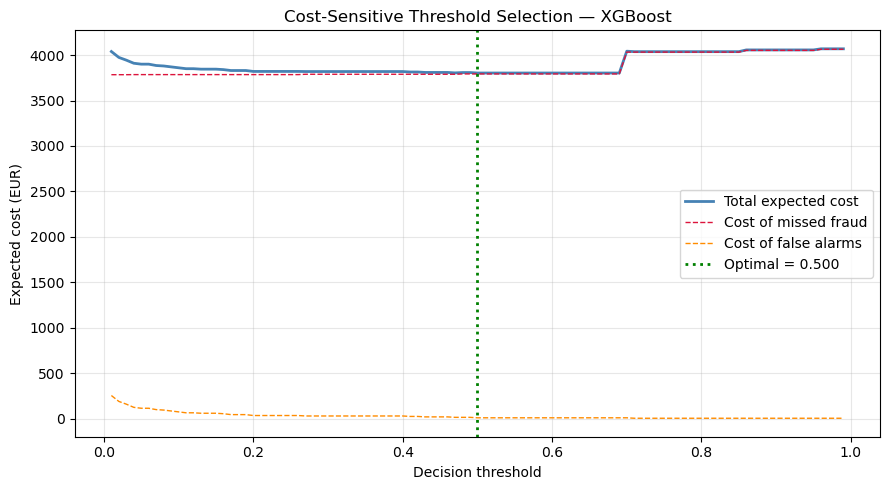

In [15]:
# ============================================
# CELL 14 (FIXED): Cost-sensitive threshold analysis
# ============================================

# Reload the original file to recover the untouched Amount column in euros.
# The df in memory has already been scaled, so those values are no longer readable.
df_raw = pd.read_csv('creditcard.csv').drop_duplicates()

# X_test keeps the original row indices, so amounts can be matched exactly.
amounts_eur = df_raw.loc[X_test.index, 'Amount'].values

# Sanity check — these should look like genuine transaction amounts
print("Amount check (EUR):")
print("  min    :", round(amounts_eur.min(), 2))
print("  median :", round(np.median(amounts_eur), 2))
print("  max    :", round(amounts_eur.max(), 2))
print("  total fraud value in test set:",
      round(amounts_eur[y_test.values == 1].sum(), 2))
print()

COST_FALSE_ALARM = 5.0   # euros per manual review

records = []
for t in np.linspace(0.01, 0.99, 99):
    pred = (y_proba >= t).astype(int)

    missed = (y_test.values == 1) & (pred == 0)
    cost_fn = amounts_eur[missed].sum()

    false_alarms = ((y_test.values == 0) & (pred == 1)).sum()
    cost_fp = false_alarms * COST_FALSE_ALARM

    records.append({
        'threshold'     : t,
        'frauds_missed' : missed.sum(),
        'false_alarms'  : false_alarms,
        'cost_missed'   : cost_fn,
        'cost_alarms'   : cost_fp,
        'total_cost'    : cost_fn + cost_fp,
    })

cost_df = pd.DataFrame(records)
optimal = cost_df.loc[cost_df['total_cost'].idxmin()]

print("=" * 60)
print("COST-SENSITIVE THRESHOLD ANALYSIS")
print("=" * 60)
print(f"Cost-optimal threshold : {optimal['threshold']:.3f}")
print(f"  Frauds missed        : {int(optimal['frauds_missed'])}")
print(f"  False alarms         : {int(optimal['false_alarms'])}")
print(f"  Total expected cost  : EUR {optimal['total_cost']:,.2f}")
print()

default_row = cost_df.iloc[(cost_df['threshold'] - 0.5).abs().idxmin()]
print(f"Default threshold 0.50 : EUR {default_row['total_cost']:,.2f}")
print(f"Saving vs default      : EUR {default_row['total_cost'] - optimal['total_cost']:,.2f}")

# ---- Plot ----
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cost_df['threshold'], cost_df['total_cost'],
        color='steelblue', lw=2, label='Total expected cost')
ax.plot(cost_df['threshold'], cost_df['cost_missed'],
        color='crimson', ls='--', lw=1, label='Cost of missed fraud')
ax.plot(cost_df['threshold'], cost_df['cost_alarms'],
        color='darkorange', ls='--', lw=1, label='Cost of false alarms')
ax.axvline(optimal['threshold'], color='green', ls=':', lw=2,
           label=f"Optimal = {optimal['threshold']:.3f}")

ax.set_xlabel('Decision threshold')
ax.set_ylabel('Expected cost (EUR)')
ax.set_title('Cost-Sensitive Threshold Selection — XGBoost')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/05_cost_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

cost_df.to_csv('outputs/05_cost_analysis.csv', index=False)

## 15. Explainability with SHAP

The project requires identifying which features most influence fraud
predictions. SHAP is used here.

**What SHAP does**

SHAP assigns each feature a contribution value for every individual
prediction, quantifying how much it pushed that prediction towards fraud or
away from it. Averaging the absolute contributions across many predictions
gives a global ranking of feature influence.

The name comes from Shapley values in cooperative game theory, which answer
the analogous question of how to fairly divide credit for a team's outcome
among its members.

**An important limitation**

V1–V28 are anonymised PCA components. The original features — merchant,
location, card metadata and so on — were confidential and were transformed
before release.

This means SHAP can establish that V14 and V17 carry the most predictive
weight, but it cannot say what those components represent in business terms.
The explanation is mathematically valid and operationally useless: a fraud
analyst cannot act on "V14 was low". In a production system built on
non-anonymised features, the same analysis would yield directly actionable
insight.

A subsample of 2,000 test rows is used, as exact SHAP computation over the
full test set is expensive.

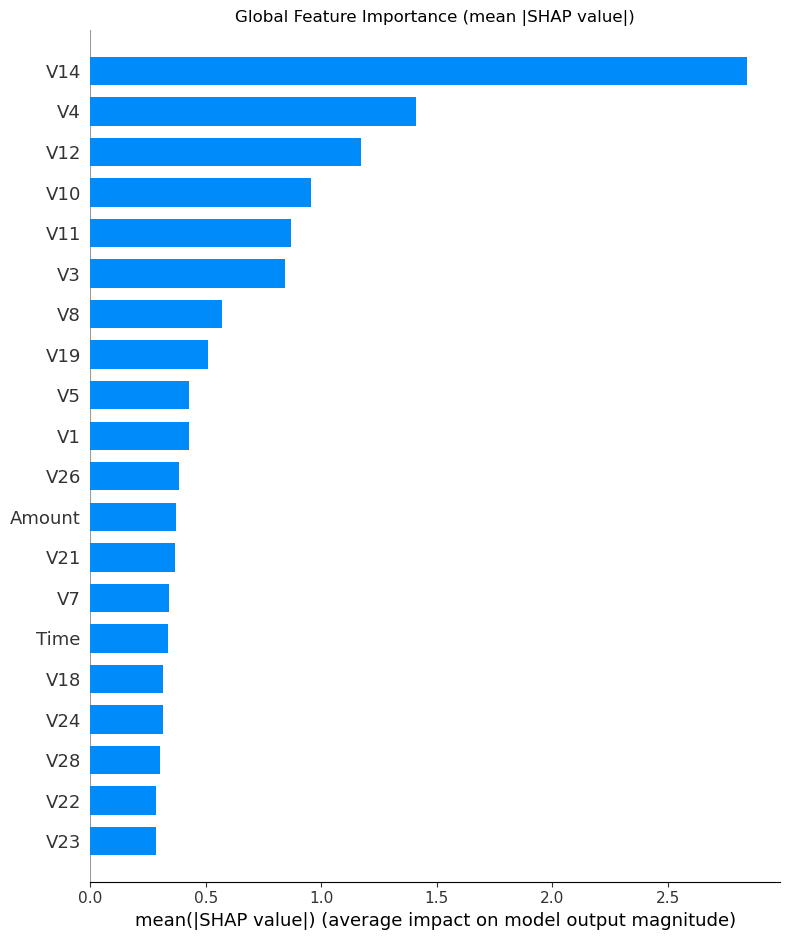

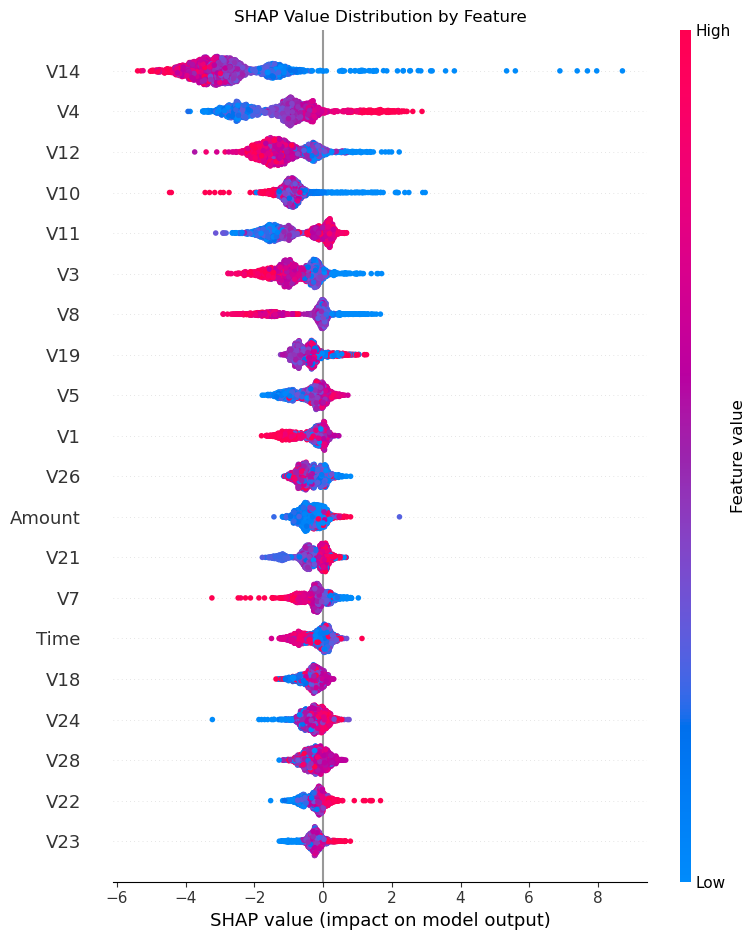

Top 10 most influential features:
feature  mean_abs_shap
    V14       2.842949
     V4       1.408090
    V12       1.170535
    V10       0.953102
    V11       0.867265
     V3       0.842323
     V8       0.567672
    V19       0.508237
     V5       0.427847
     V1       0.424483


In [16]:
# ============================================
# CELL 15: SHAP feature importance
# ============================================

import shap

# Subsample for tractability — exact SHAP over 56,000 rows is very slow
X_shap = X_test.sample(2000, random_state=42)

# TreeExplainer is the exact, optimised algorithm for tree ensembles
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

# Global ranking: mean absolute SHAP value per feature
shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False)
plt.title('Global Feature Importance (mean |SHAP value|)')
plt.tight_layout()
plt.savefig('outputs/06_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm plot: shows direction as well as magnitude.
# Red = high feature value, blue = low. Position on the x-axis shows whether
# that value pushed the prediction towards fraud (right) or away (left).
shap.summary_plot(shap_values, X_shap, show=False)
plt.title('SHAP Value Distribution by Feature')
plt.tight_layout()
plt.savefig('outputs/07_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the top ten for the written report
importance = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).head(10)

print("Top 10 most influential features:")
print(importance.to_string(index=False))

## 16. Model drift simulation

Fraud models degrade over time. Fraudsters adapt, spending patterns shift, and
a model trained on last year's behaviour gradually loses accuracy on this
year's transactions. Detecting that decay is a standard production concern.

**Method**

Rather than splitting randomly, the data is ordered by `Time` and cut in half.
The model trains on the earlier period and is tested on the later one,
simulating deployment against genuinely future transactions.

**Why `Time` is dropped as a feature here**

Under a chronological split, every `Time` value in the test set lies outside
the range seen during training. A tree-based model cannot extrapolate beyond
the ranges it was fitted on, so leaving `Time` in would produce degradation
caused by that artefact rather than by real drift.

**Expected outcome**

This dataset covers only two days. Genuine drift operates over months, so a
dramatic drop is not expected. A stable result here is a valid finding, not a
failed experiment — the methodology is what transfers to a longer horizon.

In [17]:
# ============================================
# CELL 16: Chronological split — drift simulation
# ============================================

# Reload the raw file: the in-memory df has a scaled Time column
df_drift = pd.read_csv('creditcard.csv').drop_duplicates()
df_drift = df_drift.sort_values('Time').reset_index(drop=True)

# Split chronologically at the midpoint
half = len(df_drift) // 2
train_period = df_drift.iloc[:half]
test_period  = df_drift.iloc[half:]

# Drop Time itself for the reason explained above
X_early = train_period.drop(['Class', 'Time'], axis=1)
y_early = train_period['Class']
X_late  = test_period.drop(['Class', 'Time'], axis=1)
y_late  = test_period['Class']

# Scale Amount using statistics from the training period only
scaler_drift = RobustScaler()
X_early[['Amount']] = scaler_drift.fit_transform(X_early[['Amount']])
X_late[['Amount']]  = scaler_drift.transform(X_late[['Amount']])

print("Early period :", len(X_early), "rows |", y_early.sum(), "frauds")
print("Late period  :", len(X_late), "rows |", y_late.sum(), "frauds")
print()

# Train on the early period only
ratio_drift = (y_early == 0).sum() / (y_early == 1).sum()
model_drift = XGBClassifier(scale_pos_weight=ratio_drift, eval_metric='aucpr',
                            random_state=42, n_jobs=-1)
model_drift.fit(X_early, y_early)

# Evaluate on the later period
proba_late = model_drift.predict_proba(X_late)[:, 1]
pr_auc_late = average_precision_score(y_late, proba_late)

# Baseline: the random split result from Section 3.3
print("=" * 55)
print("DRIFT ANALYSIS")
print("=" * 55)
print(f"Random split PR-AUC (Section 3.3) : {pr_auc:.4f}")
print(f"Chronological split PR-AUC        : {pr_auc_late:.4f}")
print(f"Difference                        : {pr_auc_late - pr_auc:+.4f}")
print()

if abs(pr_auc_late - pr_auc) < 0.05:
    print("No meaningful degradation over this two-day window.")
else:
    print("Performance shift detected between the two periods.")

Early period : 141863 rows | 262 frauds
Late period  : 141863 rows | 211 frauds

DRIFT ANALYSIS
Random split PR-AUC (Section 3.3) : 0.8251
Chronological split PR-AUC        : 0.7755
Difference                        : -0.0496

No meaningful degradation over this two-day window.


## 17. Saving the final model artifact

The trained model is persisted for reuse, satisfying the deliverable
requirement for a saved model or pipeline artifact.

**The scaler is saved alongside the model, not separately**

A model on its own is not deployable. It was trained on scaled inputs, so any
incoming transaction must be scaled using the *same* median and interquartile
range that were fitted on the training data. Refitting a scaler on new data
would shift those statistics and silently corrupt every prediction.

This is one of the most common failure modes in deploying a model: the
notebook works, the saved model does not, and the discrepancy is difficult to
trace because nothing raises an error — the predictions are simply wrong.

**The threshold is stored with the artifact**

The cost-optimal threshold is part of the model's operating configuration, not
an incidental detail. Storing it separately, or leaving it to be rediscovered,
invites someone downstream to fall back on the default 0.5 and discard the
entire cost analysis.

**Contents of the artifact**

| Key | Purpose |
|---|---|
| `pipeline` | The trained XGBoost classifier |
| `scaler` | The fitted RobustScaler for `Amount` and `Time` |
| `threshold` | The cost-optimal decision threshold |
| `features` | Column order, so inputs can be validated at scoring time |

Storing the feature list guards against silent column-order mismatches, which
produce plausible-looking but entirely incorrect predictions.

In [18]:
# ============================================
# CELL 17: Save the final pipeline
# ============================================

import joblib
from sklearn.pipeline import Pipeline as SkPipeline

# The scaler is saved together with the model. Saving the model alone would
# be useless: incoming transactions must be scaled with the same statistics
# the model was trained on.
final_pipeline = SkPipeline([
    ('model', best_model)
])

artifact = {
    'pipeline'  : final_pipeline,
    'scaler'    : scaler,
    'threshold' : float(optimal['threshold']),
    'features'  : list(X_train.columns),
}

joblib.dump(artifact, 'outputs/fraud_model.joblib')
print("Model artifact saved to: outputs/fraud_model.joblib")
print("  Threshold stored:", round(artifact['threshold'], 3))

Model artifact saved to: outputs/fraud_model.joblib
  Threshold stored: 0.5


## 18. Stretch goal — real-time scoring simulation

The stretch goal asks for a simulated live scoring loop: transactions fed
through the trained pipeline one at a time, with flagged frauds written to an
output log, as if scoring a production transaction stream.

**Why one row at a time**

Batch scoring is faster, but it does not resemble production. A real fraud
system receives a single transaction, must score it within milliseconds, and
must decide before the payment completes. Scoring row by row surfaces the
constraints that batch evaluation hides — per-transaction latency, and the
fact that the model artifact must be loaded once and reused rather than
refitted.

**Loading from the saved artifact**

The model, scaler and threshold are loaded from the `.joblib` file written in
Section 17 rather than reused from memory. This verifies that the saved
artifact is genuinely self-contained and would work in a fresh process, which
is the only meaningful test of whether it was saved correctly.

**Output**

Every transaction that scores above the cost-optimal threshold is appended to
`outputs/flagged_transactions.csv`, along with its fraud probability and true
label, so the log can be audited afterwards.

In [19]:
# ============================================
# CELL 18: Real-time scoring simulation (stretch goal)
# ============================================

import joblib
import time
import csv

# Load everything from the saved artifact — nothing is reused from memory.
# This proves the artifact would work in a fresh process.
artifact = joblib.load('outputs/fraud_model.joblib')
loaded_model     = artifact['pipeline']
loaded_threshold = artifact['threshold']
loaded_features  = artifact['features']

print("Artifact loaded")
print("  Threshold :", round(loaded_threshold, 4))
print("  Features  :", len(loaded_features))
print()

# Simulate a stream using the first 5,000 test transactions.
# The full test set would work identically but takes considerably longer.
STREAM_SIZE = 5000
stream = X_test.iloc[:STREAM_SIZE]
stream_labels = y_test.iloc[:STREAM_SIZE]

log_path = 'outputs/flagged_transactions.csv'
flagged = 0
latencies = []

with open(log_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['row_index', 'fraud_probability', 'threshold', 'true_label'])

    print(f"Scoring {STREAM_SIZE} transactions one at a time ...")
    stream_start = time.time()

    for idx in range(STREAM_SIZE):
        # A single transaction arrives. Reshaped to (1, n_features) because
        # the model expects a 2D input even for one row.
        row = stream.iloc[[idx]]

        t0 = time.perf_counter()
        prob = loaded_model.predict_proba(row)[0, 1]
        latencies.append((time.perf_counter() - t0) * 1000)   # milliseconds

        # Apply the cost-optimal threshold, not the default 0.5
        if prob >= loaded_threshold:
            writer.writerow([
                int(stream.index[idx]),
                round(float(prob), 6),
                round(loaded_threshold, 4),
                int(stream_labels.iloc[idx])
            ])
            flagged += 1

    elapsed = time.time() - stream_start

# ---- Results ----
actual_frauds = int(stream_labels.sum())

print("done\n")
print("=" * 55)
print("REAL-TIME SCORING SIMULATION")
print("=" * 55)
print(f"Transactions processed : {STREAM_SIZE}")
print(f"Actual frauds present  : {actual_frauds}")
print(f"Transactions flagged   : {flagged}")
print()
print(f"Total time             : {elapsed:.1f} s")
print(f"Mean latency           : {np.mean(latencies):.2f} ms per transaction")
print(f"95th percentile        : {np.percentile(latencies, 95):.2f} ms")
print(f"Throughput             : {STREAM_SIZE / elapsed:,.0f} transactions/second")
print()
print(f"Log written to: {log_path}")

# Show what was actually logged
flagged_log = pd.read_csv(log_path)
if len(flagged_log) > 0:
    caught = (flagged_log['true_label'] == 1).sum()
    print(f"\nOf {flagged} flagged transactions, {caught} were genuine fraud "
          f"({caught/flagged*100:.1f}% precision at this threshold).")
    print("\nFirst few entries:")
    print(flagged_log.head().to_string(index=False))
else:
    print("\nNo transactions exceeded the threshold in this sample.")

Artifact loaded
  Threshold : 0.5
  Features  : 30

Scoring 5000 transactions one at a time ...
done

REAL-TIME SCORING SIMULATION
Transactions processed : 5000
Actual frauds present  : 6
Transactions flagged   : 4

Total time             : 30.2 s
Mean latency           : 5.65 ms per transaction
95th percentile        : 6.26 ms
Throughput             : 166 transactions/second

Log written to: outputs/flagged_transactions.csv

Of 4 flagged transactions, 4 were genuine fraud (100.0% precision at this threshold).

First few entries:
 row_index  fraud_probability  threshold  true_label
    116139           0.999372        0.5           1
     95597           0.999995        0.5           1
    203700           0.999989        0.5           1
    143188           0.999994        0.5           1


## 19. Permutation importance — cross-checking SHAP

The project accepts either SHAP or permutation importance. Both are reported
here because they answer the same question by unrelated routes, and agreement
between them is evidence rather than repetition.

SHAP decomposes each individual prediction into per-feature contributions.
Permutation importance instead shuffles one column at a time and measures how
far PR-AUC falls: if breaking a feature's relationship with the target barely
moves the score, that feature was not carrying much signal.

PR-AUC is used as the scoring function, consistent with the metric used
throughout this notebook.

Top 10 features by permutation importance (drop in PR-AUC):
feature  importance    std
    V14      0.2545 0.0571
     V4      0.0769 0.0006
 Amount      0.0583 0.0167
    V11      0.0557 0.0144
     V3      0.0400 0.0101
     V6      0.0395 0.0116
    V19      0.0387 0.0070
    V28      0.0339 0.0223
    V12      0.0326 0.0122
     V8      0.0251 0.0183


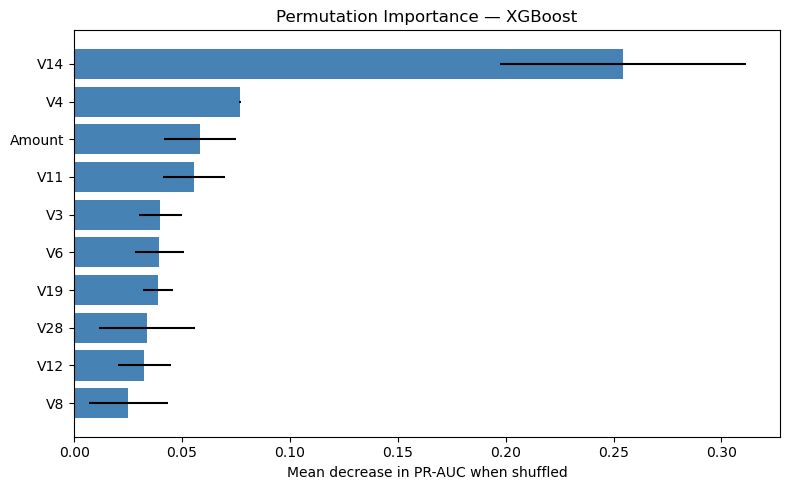

In [20]:
# ============================================
# CELL 19: Permutation importance (cross-check on SHAP)
# ============================================

from sklearn.inspection import permutation_importance

# Permutation importance works differently from SHAP: it shuffles one column
# at a time and measures how much the score drops. If shuffling a feature
# barely changes performance, that feature was not carrying much signal.
# Because the two methods are unrelated, agreement between them is meaningful
# evidence rather than a repeated measurement.

X_perm = X_test.sample(5000, random_state=42)
y_perm = y_test.loc[X_perm.index]

perm = permutation_importance(
    best_model, X_perm, y_perm,
    scoring='average_precision',   # PR-AUC, consistent with the rest of the notebook
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_perm.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std
}).sort_values('importance', ascending=False).head(10)

print("Top 10 features by permutation importance (drop in PR-AUC):")
print(perm_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(perm_df['feature'][::-1], perm_df['importance'][::-1],
        xerr=perm_df['std'][::-1], color='steelblue')
ax.set_xlabel('Mean decrease in PR-AUC when shuffled')
ax.set_title('Permutation Importance — XGBoost')
plt.tight_layout()
plt.savefig('outputs/08_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()